# DBSCAN — Density-Based Clustering for Condition Monitoring

### Lecture notebook · unsupervised learning with scikit-learn

**Case study:** a fleet of motor-driven process pumps is instrumented with four sensor
channels. Nobody has labelled the data. We want the machine to tell us, on its own:

1. **How many distinct duty regimes is this fleet actually running in?** (idle / nominal / high-load?)
2. **Which readings do not belong to any regime?** — those are the candidates for a maintenance work order.

DBSCAN answers both questions at once, because it is the rare clustering algorithm that is
allowed to say *"this point belongs to nothing."*

---

### Learning objectives

By the end of this notebook you should be able to:

- state the definitions of **core point, border point, noise point**, and of the two
  parameters **ε (`eps`)** and **MinPts (`min_samples`)**;
- explain why DBSCAN finds arbitrarily-shaped clusters where K-Means cannot;
- choose ε from a **k-distance plot** instead of guessing;
- run `sklearn.cluster.DBSCAN` on multi-channel sensor data and read
  `labels_` and `core_sample_indices_`;
- evaluate a clustering **without labels** (silhouette, noise rate) and **with** labels when
  you are lucky enough to have some;
- explain why DBSCAN has **no `.predict()`** and implement a sensible assignment rule for new readings;
- recognise the failure mode of DBSCAN (**varying density**) and name the fix (OPTICS / HDBSCAN).

## 0. Setup

Everything below runs on a standard scientific-Python stack. No internet access and no
external data files are needed — the sensor data is simulated in Section 1 with a fixed seed,
so every run of this notebook gives identical numbers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans, OPTICS, HDBSCAN
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             precision_score, recall_score, confusion_matrix)
from sklearn.datasets import make_moons

RANDOM_STATE = 7
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

import sklearn
print("scikit-learn", sklearn.__version__)

scikit-learn 1.7.0


---
# 1. The engineering problem

## 1.1 The asset and its instrumentation

We monitor **motor-driven centrifugal pumps** on a process line. Each pump reports four
channels once per hour:

| channel | symbol | why it matters |
|---|---|---|
| `vibration_rms_mm_s` | broadband velocity RMS at the drive-end bearing | the ISO 10816 severity measure — rises with unbalance, misalignment and bearing wear |
| `bearing_temp_C` | bearing-housing temperature | rises with friction, lubrication loss and overload |
| `motor_current_A` | RMS line current of the driving motor | a proxy for hydraulic load / duty point |
| `acoustic_hf` | normalised high-frequency acoustic-emission band energy | the **earliest** indicator of a rolling-element spall, long before vibration RMS moves |

## 1.2 Why unsupervised learning?

In a real plant you almost never have a labelled fault history: failures are rare, the
CMMS work orders are free text, and nobody tagged the sensor archive. What you *do* have is
a large pile of unlabelled readings. So we cluster.

The simulator below **does** generate ground-truth states, but only so that we can *score*
ourselves at the end. DBSCAN never sees them.

In [2]:
FEATURES = ["vibration_rms_mm_s", "bearing_temp_C", "motor_current_A", "acoustic_hf"]

def make_machine_data(seed=RANDOM_STATE):
    """Simulate ~900 hourly readings from a fleet of motor-driven pumps.

    Three healthy duty regimes, plus two families of abnormal reading:
    incipient bearing damage (late in life) and sensor drop-outs.
    """
    rng = np.random.default_rng(seed)

    def regime(n, vib, temp, cur, ac, s=(0.16, 2.0, 0.9, 0.020)):
        return np.column_stack([rng.normal(vib, s[0], n), rng.normal(temp, s[1], n),
                                rng.normal(cur, s[2], n), rng.normal(ac,  s[3], n)])

    idle    = regime(240, 0.95, 42.0,  8.5, 0.15)   # recirculation / standby
    nominal = regime(400, 2.10, 58.0, 18.0, 0.22)   # normal production duty
    high    = regime(230, 3.35, 70.0, 27.0, 0.30)   # high-flow campaign

    # Incipient bearing damage: vibration and HF acoustic energy climb and scatter widely,
    # so these readings sit in a LOW-DENSITY part of the feature space.
    n_f = 26
    fault = np.column_stack([rng.normal(6.2, 1.5, n_f), rng.normal(77.0, 6.0, n_f),
                             rng.normal(21.0, 5.0, n_f), rng.normal(0.72, 0.18, n_f)])

    # Instrumentation drop-outs / stuck channels.
    n_d = 12
    drop = np.column_stack([rng.normal(0.05, 0.03, n_d), rng.normal(20.0, 4.0, n_d),
                            rng.normal(0.60, 0.40, n_d), rng.normal(0.01, 0.01, n_d)])

    X = np.vstack([idle, nominal, high, fault, drop])
    truth = np.array(["idle"]*240 + ["nominal"]*400 + ["high_load"]*230
                     + ["bearing_fault"]*n_f + ["sensor_dropout"]*n_d)

    hours = np.empty(len(X))
    hours[:870]              = rng.uniform(0, 1080, 870)     # healthy: whole campaign
    hours[870:870+n_f]       = rng.uniform(700, 1080, n_f)   # faults: final third (degradation)
    hours[870+n_f:]          = rng.uniform(0, 1080, n_d)

    order = np.argsort(hours)
    df = pd.DataFrame(X[order], columns=FEATURES)
    df.insert(0, "hours_in_service", np.round(hours[order], 1))
    df["true_state"] = truth[order]            # <-- for SCORING ONLY
    df[FEATURES] = df[FEATURES].round(3)
    return df.reset_index(drop=True)

df = make_machine_data()
print(df.shape)
df.head()

(908, 6)


,hours_in_service,vibration_rms_mm_s,bearing_temp_C,motor_current_A,acoustic_hf,true_state
0,1.9,2.246,55.908,19.902,0.242,nominal
1,2.7,3.309,68.570,27.795,0.330,high_load
2,3.2,3.230,73.525,26.912,0.323,high_load
3,3.5,2.238,57.571,18.891,0.216,nominal
4,4.0,0.991,41.796,8.160,0.148,idle


In [3]:
# What the (hidden) truth looks like -- we peek once, then put it away.
df.groupby("true_state")[FEATURES].agg(["mean", "count"]).round(2)

vibration_rms_mm_s       bearing_temp_C       motor_current_A  \
                             mean count           mean count            mean   
true_state                                                                     
bearing_fault                6.02    26          75.39    26           19.61   
high_load                    3.36   230          69.81   230           27.13   
idle                         0.93   240          41.81   240            8.44   
nominal                      2.10   400          57.95   400           18.05   
sensor_dropout               0.06    12          18.98    12            0.33   

                     acoustic_hf        
               count        mean count  
true_state                              
bearing_fault     26        0.72    26  
high_load        230        0.30   230  
idle             240        0.15   240  
nominal          400        0.22   400  
sensor_dropout    12        0.01    12

## 1.3 Look at the data first

Two habits worth keeping: plot before you model, and note the **units**. Bearing temperature
runs to ~80 (°C) while `acoustic_hf` lives in [0, 1]. Any distance-based method — and DBSCAN
is entirely built on distance — will be dominated by whichever channel happens to have the
biggest numbers. We will fix that in Section 2.2.

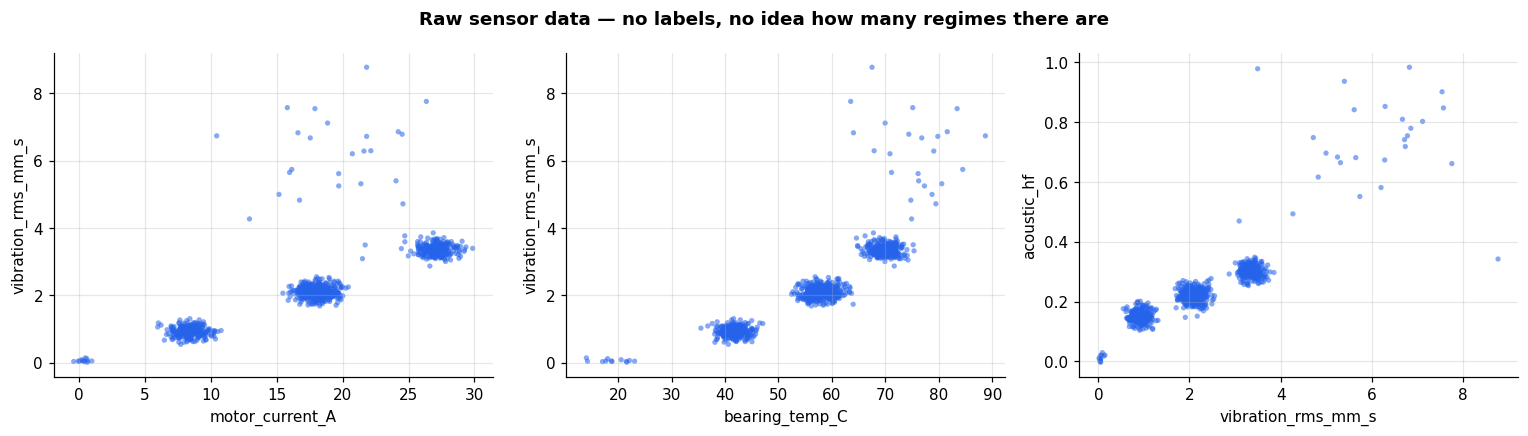

       vibration_rms_mm_s  bearing_temp_C  motor_current_A  acoustic_hf
count              908.00          908.00           908.00       908.00
mean                 2.19           56.67            17.62         0.23
std                  1.15           11.70             7.11         0.11
min                  0.02           14.07            -0.41        -0.00
25%                  1.10           44.22             9.48         0.17
50%                  2.10           57.84            17.99         0.22
75%                  3.16           67.34            25.03         0.28
max                  8.77           88.71            29.87         0.98


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [("motor_current_A", "vibration_rms_mm_s"),
         ("bearing_temp_C",  "vibration_rms_mm_s"),
         ("vibration_rms_mm_s", "acoustic_hf")]
for ax, (a, b) in zip(axes, pairs):
    ax.scatter(df[a], df[b], s=12, c="#2563eb", alpha=0.55, ec="none")
    ax.set_xlabel(a); ax.set_ylabel(b)
fig.suptitle("Raw sensor data — no labels, no idea how many regimes there are", fontweight="bold")
fig.tight_layout()
plt.show()

print(df[FEATURES].describe().round(2))

Even by eye you can see **three dense knots** and a **sparse smear** heading to the upper right.
That sparse smear is exactly what DBSCAN is designed to isolate.

---
# 2. DBSCAN in one page

## 2.1 The definitions

DBSCAN (Ester, Kriegel, Sander & Xu, KDD 1996) has **two parameters**:

- **ε (`eps`)** — the neighbourhood radius;
- **MinPts (`min_samples`)** — how many points must lie inside that radius for the
  neighbourhood to count as *dense*. (scikit-learn counts the point itself.)

Every point is then one of three kinds:

| kind | definition | in scikit-learn |
|---|---|---|
| **core** | has **≥ MinPts** points within distance ε | index appears in `core_sample_indices_` |
| **border** | fewer than MinPts neighbours, **but** lies within ε of a core point | `labels_ ≥ 0`, not a core index |
| **noise** | neither | `labels_ == -1` |

A **cluster** is a maximal set of points connected through chains of core points
(*density-reachability*). Consequences worth saying out loud in the lecture:

- you **do not** specify the number of clusters — density decides it;
- clusters can be any shape (a banana, a ring, an S-curve), because the rule is local;
- **noise is a first-class output**, which is precisely what makes DBSCAN an anomaly detector
  as well as a clustering algorithm.

## 2.2 Standardise first — always

Distance means nothing until the channels share a scale. Here is the same DBSCAN run on raw
and on standardised features:

In [5]:
X_raw = df[FEATURES].values
X = StandardScaler().fit_transform(X_raw)          # <-- the input we will use everywhere

for name, data, eps in [("RAW units", X_raw, 0.30), ("STANDARDISED", X, 0.30)]:
    lab = DBSCAN(eps=eps, min_samples=8).fit_predict(data)
    n_clusters = len(set(lab) - {-1})
    print(f"{name:>14s}  eps={eps}:  {n_clusters} clusters, {(lab == -1).sum():4d} points called noise")

     RAW units  eps=0.3:  10 clusters,  768 points called noise
  STANDARDISED  eps=0.3:  3 clusters,   42 points called noise


On raw units almost everything becomes noise, because a radius of 0.30 is meaningless when
temperature spans 40 units. Standardising puts all four channels on a common footing, so
"0.30" means *0.3 standard deviations in 4-D space*.

> **Teaching note.** `StandardScaler` is the right default when channels are roughly Gaussian.
> If a channel has heavy tails or hard physical bounds, consider `RobustScaler` or a log
> transform instead — but *some* scaling is non-negotiable.

---
# 3. Choosing the parameters

## 3.1 MinPts

Rules of thumb from the literature and from practice:

- **MinPts ≥ d + 1**, and preferably **MinPts ≥ 2·d**, where *d* is the number of features.
  With d = 4 that suggests 5–8.
- Larger MinPts ⇒ more points labelled noise, but more robust clusters. Noisy industrial data
  usually wants the larger end.
- MinPts is the *less* sensitive of the two knobs. Fix it first, then tune ε.

We take **MinPts = 8** (= 2·d).

## 3.2 ε from the k-distance plot

The standard recipe: for every point compute the distance to its **k-th** nearest neighbour
(k = MinPts − 1, or just MinPts — the plot barely changes), sort those distances ascending,
and plot. Points inside a dense cluster have small k-distances; outliers have large ones.
The **knee** of the curve is the natural ε: it is the radius at which "dense" stops meaning
anything.

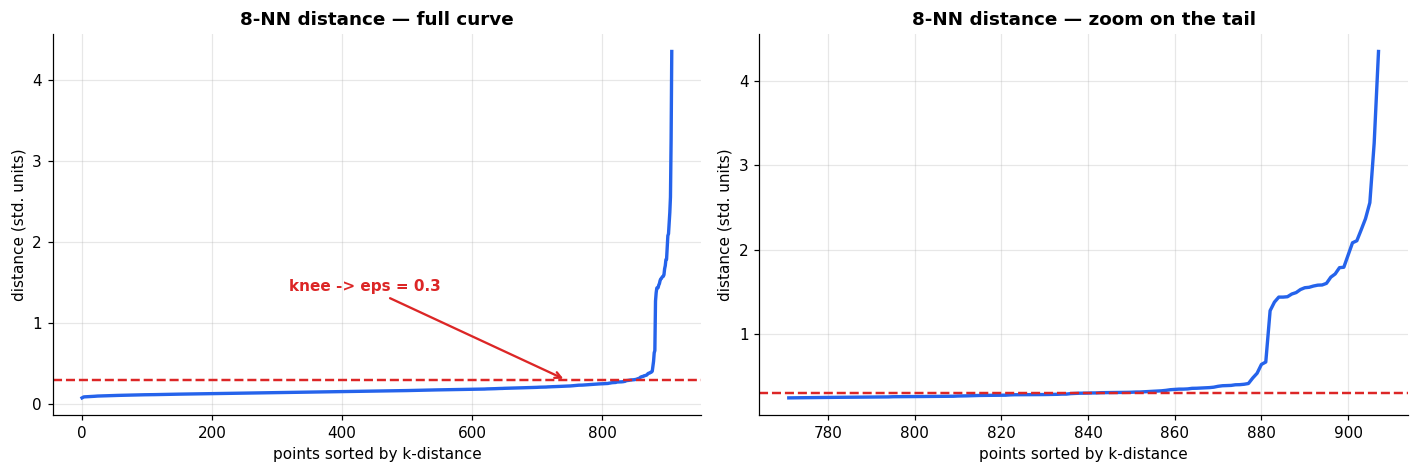

50th percentile of the 8-NN distance: 0.163
90th percentile of the 8-NN distance: 0.268
95th percentile of the 8-NN distance: 0.342
97th percentile of the 8-NN distance: 0.614
99th percentile of the 8-NN distance: 1.780


In [6]:
MIN_SAMPLES = 8

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES + 1).fit(X)   # +1 because the 1st neighbour is the point itself
distances, _ = nn.kneighbors(X)
k_dist = np.sort(distances[:, -1])

EPS = 0.30   # read off the knee below

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, (lo, hi, title) in zip(axes, [(0, len(k_dist), "full curve"),
                                      (int(0.85*len(k_dist)), len(k_dist), "zoom on the tail")]):
    ax.plot(range(lo, hi), k_dist[lo:hi], lw=2.2, color="#2563eb")
    ax.axhline(EPS, color="#dc2626", ls="--", lw=1.6)
    ax.set_title(f"{MIN_SAMPLES}-NN distance — {title}", fontweight="bold")
    ax.set_xlabel("points sorted by k-distance"); ax.set_ylabel("distance (std. units)")
axes[0].annotate(f"knee -> eps = {EPS}", xy=(0.82*len(k_dist), EPS), xytext=(0.35*len(k_dist), 1.4),
                 color="#dc2626", fontweight="bold",
                 arrowprops=dict(arrowstyle="->", color="#dc2626", lw=1.5))
fig.tight_layout(); plt.show()

for p in [50, 90, 95, 97, 99]:
    print(f"{p:2d}th percentile of the {MIN_SAMPLES}-NN distance: {np.percentile(k_dist, p):.3f}")

The curve is flat near 0.15–0.20 for the bulk of the data, then turns sharply upward at about
**0.30** and explodes past 1.0 for the last ~4 % of points. So:

- ε = 0.30 keeps the dense regimes together;
- everything in that exploding tail — roughly the sparse smear we saw in the scatter plots —
  will be labelled noise.

A useful sanity check: the knee usually sits near the *(100 − expected anomaly %)*
percentile of the k-distance. We expect a few percent of abnormal readings, and the 95–97th
percentile is indeed ≈ 0.34–0.61. Good.

---
# 4. Fit DBSCAN

In [7]:
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric="euclidean").fit(X)
labels = db.labels_

core_mask = np.zeros(len(X), dtype=bool)
core_mask[db.core_sample_indices_] = True
border_mask = (labels != -1) & ~core_mask
noise_mask = labels == -1

n_clusters = len(set(labels) - {-1})
print(f"clusters found : {n_clusters}")
print(f"core points    : {core_mask.sum():4d}")
print(f"border points  : {border_mask.sum():4d}")
print(f"noise points   : {noise_mask.sum():4d}   ({100*noise_mask.mean():.1f} % of the data)")
print()
print(pd.Series(labels).value_counts().sort_index().rename("n_points").to_frame().T)

clusters found : 3
core points    :  851
border points  :   15
noise points   :   42   (4.6 % of the data)

          -1    0    1    2
n_points  42  397  230  239


**Three clusters, and a pile of noise — without ever telling the algorithm to look for three.**

## 4.1 Visualising a 4-D clustering

Our features are 4-dimensional, so we project to 2-D with PCA **for display only** — the
clustering itself was done in the full 4-D space. (Doing it the other way round, clustering on
2 PCs, throws away information; occasionally that is a deliberate choice, but be explicit about it.)

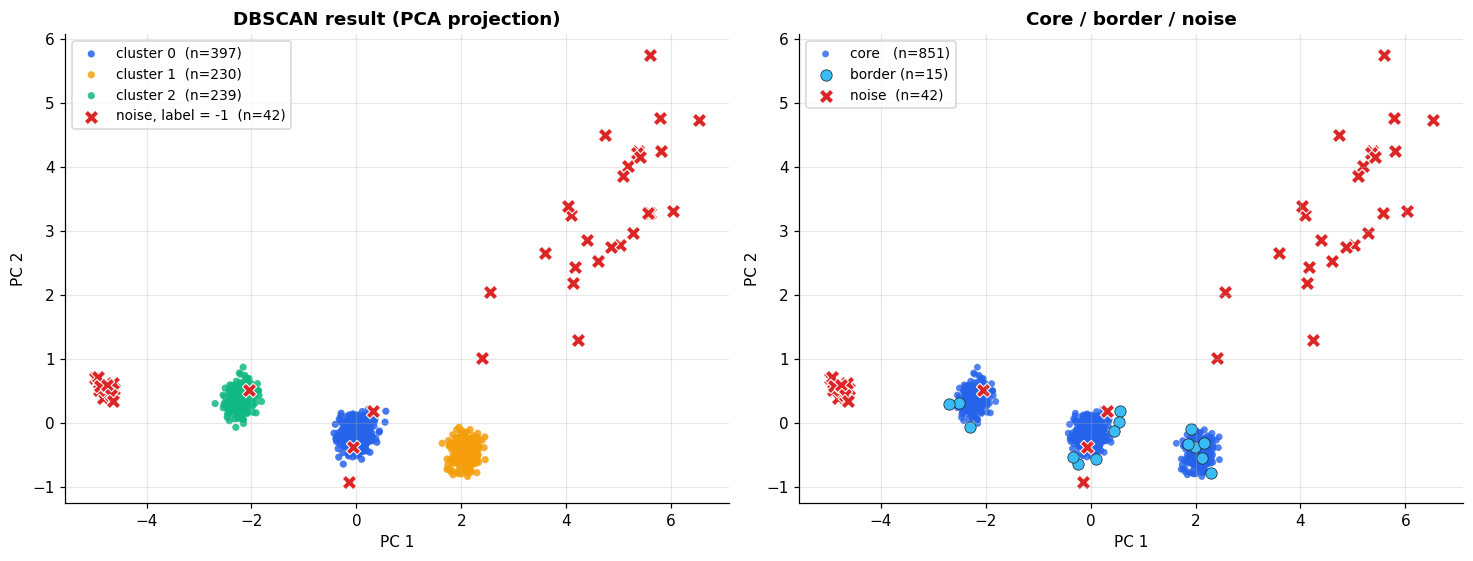

In [8]:
Z = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

palette = ["#2563eb", "#f59e0b", "#10b981", "#8b5cf6", "#0891b2"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

ax = axes[0]
for k in sorted(set(labels) - {-1}):
    m = labels == k
    ax.scatter(*Z[m].T, s=22, c=palette[k % len(palette)], alpha=.85, ec="none",
               label=f"cluster {k}  (n={m.sum()})")
ax.scatter(*Z[noise_mask].T, s=90, c="#dc2626", marker="X", ec="white", lw=.7, zorder=5,
           label=f"noise, label = -1  (n={noise_mask.sum()})")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.legend(fontsize=9)
ax.set_title("DBSCAN result (PCA projection)", fontweight="bold")

ax = axes[1]   # the same picture, but showing WHY each point got its label
ax.scatter(*Z[core_mask].T,   s=20, c="#2563eb", ec="none", alpha=.8, label=f"core   (n={core_mask.sum()})")
ax.scatter(*Z[border_mask].T, s=55, c="#38bdf8", ec="#1f2933", lw=.5,  label=f"border (n={border_mask.sum()})")
ax.scatter(*Z[noise_mask].T,  s=90, c="#dc2626", marker="X", ec="white", lw=.7, label=f"noise  (n={noise_mask.sum()})")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.legend(fontsize=9)
ax.set_title("Core / border / noise", fontweight="bold")

fig.tight_layout(); plt.show()

Notice the small tight knot of red crosses on the far left. Those are the **sensor drop-outs**:
they are mutually similar, but there are only 12 of them, so at ε = 0.30 they never reach
MinPts and stay noise. Raise ε enough and they would become a cluster of their own — which is
how you *discover a recurring fault mode* rather than merely flagging it. We test that in §7.

---
# 5. Interpreting the clusters as duty regimes

A cluster label is a number; an engineer needs a *description*. Profile the clusters in the
original physical units.

In [9]:
prof = df.copy()
prof["cluster"] = labels
summary = (prof.groupby("cluster")[FEATURES]
               .mean()
               .join(prof.groupby("cluster").size().rename("n"))
               .round(2))
display(summary)

# Name the regimes by their mean motor current (the duty proxy).
order = summary.drop(index=-1, errors="ignore").sort_values("motor_current_A").index
names = dict(zip(order, ["Regime A - idle / recirculation",
                         "Regime B - nominal production",
                         "Regime C - high-flow campaign"]))
names[-1] = "UNASSIGNED - investigate"
prof["regime"] = prof["cluster"].map(names)

for k in list(order) + [-1]:
    row = summary.loc[k]
    print(f"{names[k]:<34s} n={int(row['n']):4d} | "
          f"vib {row['vibration_rms_mm_s']:5.2f} mm/s | temp {row['bearing_temp_C']:5.1f} C | "
          f"I {row['motor_current_A']:5.1f} A | ac {row['acoustic_hf']:.2f}")

,vibration_rms_mm_s,bearing_temp_C,motor_current_A,acoustic_hf,n
cluster,,,,,
-1,3.92,57.48,13.72,0.47,42
0,2.10,57.94,18.04,0.22,397
1,3.36,69.81,27.13,0.30,230
2,0.93,41.79,8.45,0.15,239


Regime A - idle / recirculation    n= 239 | vib  0.93 mm/s | temp  41.8 C | I   8.4 A | ac 0.15
Regime B - nominal production      n= 397 | vib  2.10 mm/s | temp  57.9 C | I  18.0 A | ac 0.22
Regime C - high-flow campaign      n= 230 | vib  3.36 mm/s | temp  69.8 C | I  27.1 A | ac 0.30
UNASSIGNED - investigate           n=  42 | vib  3.92 mm/s | temp  57.5 C | I  13.7 A | ac 0.47


That table is the deliverable a reliability engineer actually wants:

- Regimes A/B/C become the **baselines**. Alarm limits should be set *per regime* — 3.4 mm/s is
  perfectly normal in Regime C and would be alarming in Regime A. This alone is a common win
  in real plants, where a single global vibration limit produces constant false alarms.
- The **UNASSIGNED** group is the work-order queue.

## 5.1 The maintenance story: when do the anomalies happen?

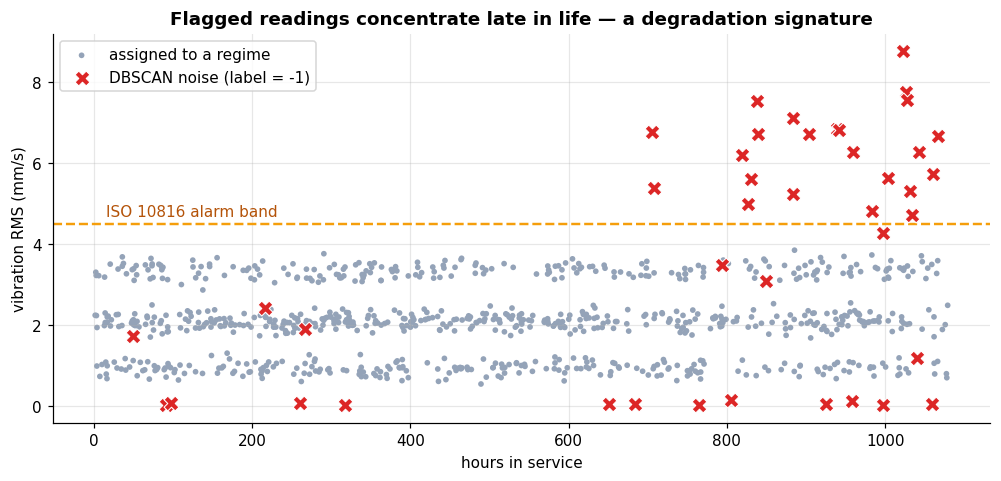

79 % of flagged readings occur after 700 h in service


In [10]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ok = labels != -1
ax.scatter(prof.hours_in_service[ok], prof.vibration_rms_mm_s[ok], s=14, c="#94a3b8",
           ec="none", label="assigned to a regime")
ax.scatter(prof.hours_in_service[~ok], prof.vibration_rms_mm_s[~ok], s=95, c="#dc2626",
           marker="X", ec="white", lw=.7, zorder=5, label="DBSCAN noise (label = -1)")
ax.axhline(4.5, color="#f59e0b", ls="--", lw=1.6)
ax.text(15, 4.7, "ISO 10816 alarm band", color="#b45309")
ax.set_xlabel("hours in service"); ax.set_ylabel("vibration RMS (mm/s)")
ax.set_title("Flagged readings concentrate late in life — a degradation signature",
             fontweight="bold")
ax.legend()
plt.show()

late = prof[~ok].hours_in_service
print(f"{(late > 700).mean()*100:.0f} % of flagged readings occur after 700 h in service")

This is the punchline for a maintenance audience. DBSCAN did not just find outliers — the
outliers **arrive in time order**, which is what distinguishes a developing bearing fault from
a random glitch. A rising count of `-1` labels per week is a perfectly good, entirely
unsupervised **health indicator** you can trend and alarm on.

---
# 6. Evaluation

## 6.1 Without labels (what you can always do)

- **Silhouette score**, computed on the non-noise points only. Including noise makes the score
  meaningless, because noise points are by construction far from everything.
- **Noise rate** — a sanity check. 30 % noise usually means ε is too small.
- **Cluster stability** under resampling or small changes in ε (see §7).

In [11]:
mask = labels != -1
print(f"silhouette (non-noise only) : {silhouette_score(X[mask], labels[mask]):.3f}")
print(f"noise rate                  : {100*(~mask).mean():.1f} %")
print(f"n clusters                  : {n_clusters}")

# The wrong way, for contrast:
print(f"\nsilhouette INCLUDING noise  : {silhouette_score(X, labels):.3f}  <- misleading, do not report this")

silhouette (non-noise only) : 0.809
noise rate                  : 4.6 %
n clusters                  : 3

silhouette INCLUDING noise  : 0.758  <- misleading, do not report this


## 6.2 With labels (only because this is a teaching example)

We happen to hold the ground truth, so let us grade two different things:

1. **Regime recovery** — do the clusters correspond to the true duty regimes? (Adjusted Rand Index)
2. **Anomaly detection** — treating `label == -1` as the alarm, what are precision and recall?

In [12]:
truth = df["true_state"].values
healthy = np.isin(truth, ["idle", "nominal", "high_load"])

ari = adjusted_rand_score(truth[healthy & mask], labels[healthy & mask])
print(f"Adjusted Rand Index on the healthy regimes : {ari:.3f}   (1.0 = perfect)\n")

print("cluster label vs. true state")
display(pd.crosstab(pd.Series(truth, name="true_state"), pd.Series(labels, name="dbscan_label")))

y_true = ~healthy                 # True = genuinely abnormal
y_pred = ~mask                    # True = DBSCAN called it noise
print(f"\nanomaly precision : {precision_score(y_true, y_pred):.3f}"
      f"   ({(y_true & y_pred).sum()} of {y_pred.sum()} alarms were real)")
print(f"anomaly recall    : {recall_score(y_true, y_pred):.3f}"
      f"   ({(y_true & y_pred).sum()} of {y_true.sum()} real faults caught)")

Adjusted Rand Index on the healthy regimes : 1.000   (1.0 = perfect)

cluster label vs. true state


dbscan_label,-1,0,1,2
true_state,,,,
bearing_fault,26,0,0,0
high_load,0,0,230,0
idle,1,0,0,239
nominal,3,397,0,0
sensor_dropout,12,0,0,0



anomaly precision : 0.905   (38 of 42 alarms were real)
anomaly recall    : 1.000   (38 of 38 real faults caught)


Recall is **1.00** — every injected bearing fault and every sensor drop-out was flagged — at a
precision of about 0.90. The handful of false alarms are ordinary readings that happened to
land in a thin part of a regime.

For a maintenance screening tool that trade-off is the right way round: a few extra
inspections are far cheaper than a missed bearing failure. If you needed higher precision you
would lower ε or raise MinPts, and lose some recall — the usual dial.

## 6.3 Contrast: what K-Means does with the same data

Where do the 38 genuinely abnormal readings end up?

kmeans_cluster   0   1
true_state            
bearing_fault   26   0
sensor_dropout   0  12

K-Means has no reject option: every fault is filed inside a healthy cluster,
silently corrupting that cluster's baseline statistics.


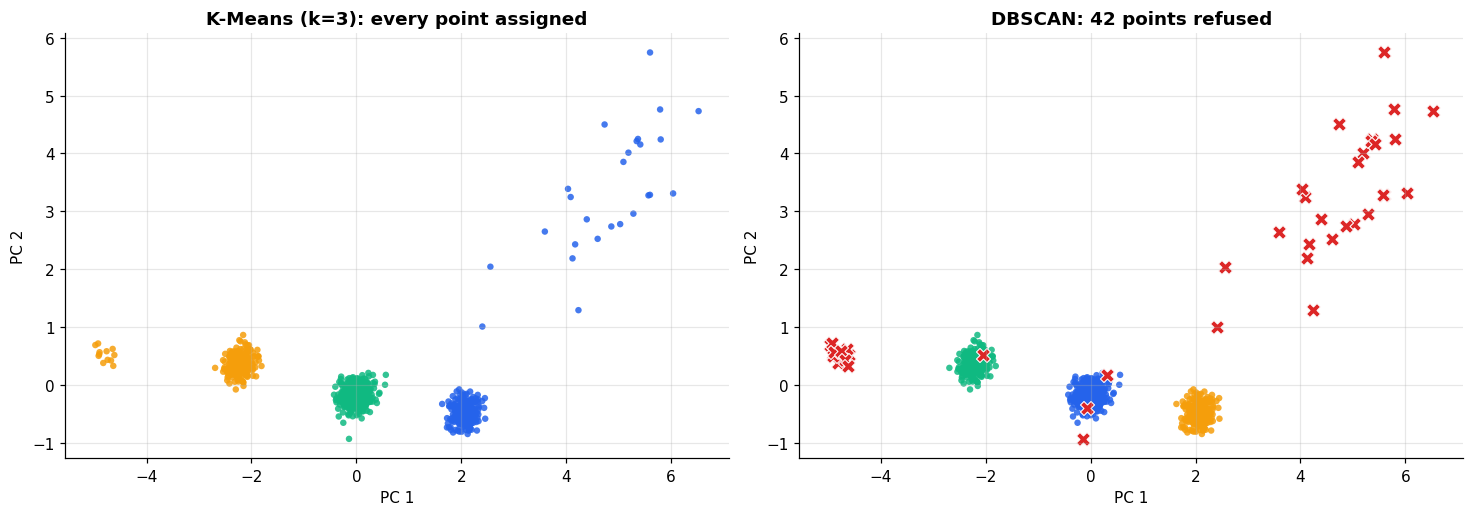

In [13]:
km = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit_predict(X)

print("Where do the 38 genuinely abnormal readings end up?\n")
print(pd.crosstab(pd.Series(truth[~healthy], name="true_state"),
                  pd.Series(km[~healthy], name="kmeans_cluster")))
print("\nK-Means has no reject option: every fault is filed inside a healthy cluster,")
print("silently corrupting that cluster's baseline statistics.")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for ax, lab, title in [(axes[0], km, "K-Means (k=3): every point assigned"),
                       (axes[1], labels, "DBSCAN: 42 points refused")]:
    for k in sorted(set(lab) - {-1}):
        m = lab == k
        ax.scatter(*Z[m].T, s=18, c=palette[k % len(palette)], alpha=.85, ec="none")
    m = lab == -1
    if m.any():
        ax.scatter(*Z[m].T, s=85, c="#dc2626", marker="X", ec="white", lw=.7)
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
fig.tight_layout(); plt.show()

## 6.4 And the classic shape argument

The textbook demonstration, worth 30 seconds of lecture time: two interleaved crescents.
K-Means cuts them with a straight line because it can only draw convex cells around centroids.
DBSCAN follows the density.

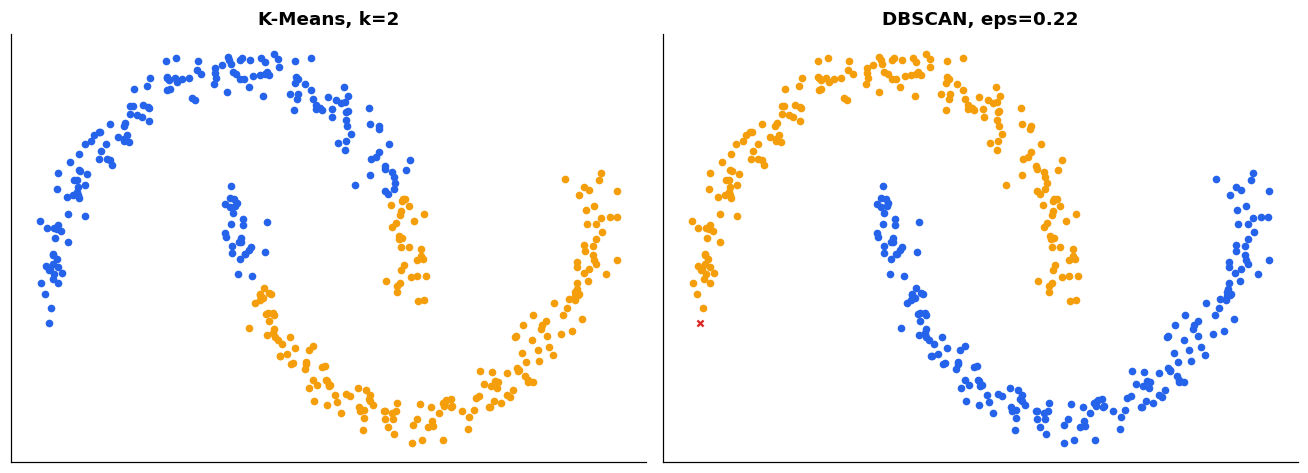

In [14]:
Xm, _ = make_moons(n_samples=400, noise=0.06, random_state=RANDOM_STATE)
Xm = StandardScaler().fit_transform(Xm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, lab, title in [(axes[0], KMeans(2, n_init=10, random_state=0).fit_predict(Xm), "K-Means, k=2"),
                       (axes[1], DBSCAN(eps=0.22, min_samples=6).fit_predict(Xm), "DBSCAN, eps=0.22")]:
    for k in sorted(set(lab)):
        m = lab == k
        c = "#dc2626" if k == -1 else palette[k % len(palette)]
        ax.scatter(*Xm[m].T, s=16, c=c, marker="x" if k == -1 else "o")
    ax.set_title(title, fontweight="bold"); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

---
# 7. Sensitivity: how much does ε matter?

A lot. This sweep is the single most useful diagnostic to run before you trust a DBSCAN
result — and a good exercise to do live in class.

,eps,n_clusters,n_noise,noise_pct,silhouette,anom_precision,anom_recall
0,0.10,2,816,89.9,0.907,0.047,1.000
1,0.15,3,267,29.4,0.841,0.142,1.000
2,0.20,3,88,9.7,0.817,0.432,1.000
3,0.25,3,46,5.1,0.810,0.826,1.000
4,0.30,3,42,4.6,0.809,0.905,1.000
5,0.40,4,27,3.0,0.809,0.963,0.684
6,0.50,4,26,2.9,0.808,1.000,0.684
7,0.75,4,26,2.9,0.808,1.000,0.684
8,1.00,4,26,2.9,0.808,1.000,0.684
9,1.50,3,5,0.6,0.516,1.000,0.132


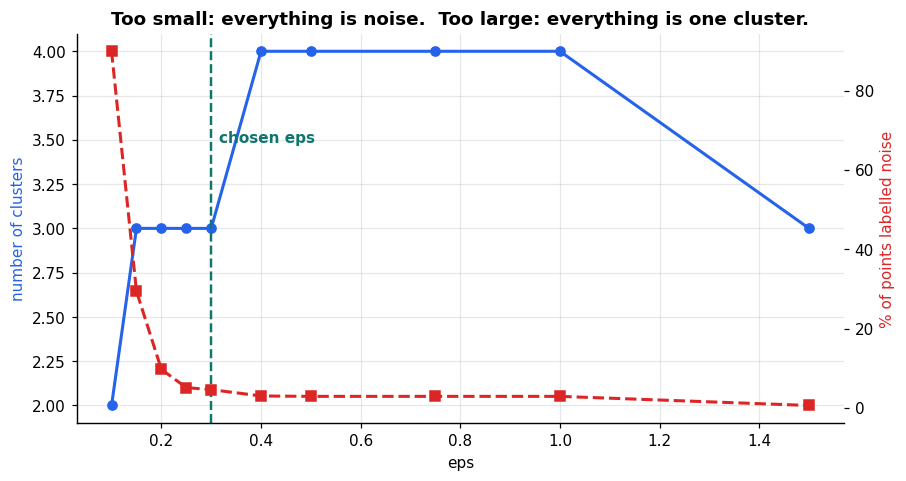

In [15]:
rows = []
for eps in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 1.00, 1.50]:
    lb = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X)
    m = lb != -1
    sil = silhouette_score(X[m], lb[m]) if len(set(lb[m])) > 1 else np.nan
    rec = recall_score(~healthy, ~m) if (~m).any() else 0.0
    prec = precision_score(~healthy, ~m, zero_division=0)
    rows.append(dict(eps=eps, n_clusters=len(set(lb) - {-1}), n_noise=int((~m).sum()),
                     noise_pct=round(100*(~m).mean(), 1), silhouette=round(sil, 3) if sil == sil else np.nan,
                     anom_precision=round(prec, 3), anom_recall=round(rec, 3)))
sweep = pd.DataFrame(rows)
display(sweep)

fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(sweep.eps, sweep.n_clusters, "o-", color="#2563eb", lw=2, label="clusters found")
ax1.set_xlabel("eps"); ax1.set_ylabel("number of clusters", color="#2563eb")
ax1.axvline(EPS, color="#0f766e", ls="--", lw=1.6)
ax1.text(EPS*1.05, ax1.get_ylim()[1]*0.85, "chosen eps", color="#0f766e", fontweight="bold")
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(sweep.eps, sweep.noise_pct, "s--", color="#dc2626", lw=2, label="% noise")
ax2.set_ylabel("% of points labelled noise", color="#dc2626")
ax1.set_title("Too small: everything is noise.  Too large: everything is one cluster.",
              fontweight="bold")
plt.show()

Read the table carefully with the class — there are three regimes of behaviour:

- **ε ≤ 0.15**: the duty regimes shatter into fragments and most healthy data is called noise.
  Recall is a perfect 1.0, but precision is terrible: it is "detecting" everything.
- **ε ≈ 0.25–0.30**: the stable plateau. Three clusters, ~5 % noise, silhouette ≈ 0.81, recall 1.00.
  The fact that the answer *does not change* over a range of ε is the real evidence that the
  structure is genuine.
- **ε ≥ 0.40**: a fourth cluster appears — the 12 sensor drop-outs are now dense enough
  *relative to ε* to satisfy MinPts among themselves. Precision rises to 1.00 but recall falls
  to 0.68, because those 12 readings are no longer flagged. Push to ε = 1.5 and the bearing
  faults are swallowed too.

That fourth cluster is worth dwelling on: it is not a bug. A group of anomalies that is
internally consistent *is* a distinct machine state — a recurring failure mode. Whether you
want it flagged as noise or named as its own cluster is an engineering decision, and ε is the
dial that expresses it.

> **The plateau is the point.** Never report a DBSCAN result from a single ε. Report the range
> of ε over which the answer is stable.

---
# 8. Deployment: DBSCAN has no `.predict()`

This surprises students, and it matters in practice. DBSCAN is **transductive** — it labels
the dataset it was fitted on and nothing else. `sklearn`'s `DBSCAN` therefore exposes
`fit_predict` but **no** `predict`. There is no centroid to compare a new point to.

The standard production pattern is to build a small nearest-core-point rule on top of the
fitted model, which reproduces exactly how DBSCAN itself would have labelled a border point:

> a new reading joins cluster *c* if it lies within ε of a **core point** of *c*;
> otherwise it is noise.

In [16]:
class DBSCANAssigner:
    """Assign new samples to a fitted DBSCAN's clusters using its core points.

    Mirrors DBSCAN's own border-point rule: within eps of a core point -> that core
    point's cluster; otherwise -1 (noise / anomaly).
    """
    def __init__(self, dbscan, X_fit):
        self.eps = dbscan.eps
        self.core_points_ = X_fit[dbscan.core_sample_indices_]
        self.core_labels_ = dbscan.labels_[dbscan.core_sample_indices_]
        self._nn = NearestNeighbors(n_neighbors=1).fit(self.core_points_)

    def predict(self, X_new):
        dist, idx = self._nn.kneighbors(X_new)
        lab = self.core_labels_[idx.ravel()]
        lab[dist.ravel() > self.eps] = -1
        return lab

scaler = StandardScaler().fit(X_raw)          # keep the fitted scaler for production!
assigner = DBSCANAssigner(db, X)

# Three incoming readings from the SCADA historian, in raw engineering units:
new_raw = np.array([
    [2.05, 57.5, 17.8, 0.21],    # looks like normal production duty
    [3.40, 70.5, 27.4, 0.31],    # looks like the high-flow campaign
    [7.10, 82.0, 22.0, 0.85],    # high vibration AND high acoustic energy -> ?
])
new_X = scaler.transform(new_raw)
pred = assigner.predict(new_X)

out = pd.DataFrame(new_raw, columns=FEATURES)
out["assigned_label"] = pred
out["verdict"] = [names.get(p, "UNASSIGNED - investigate") for p in pred]
display(out)

,vibration_rms_mm_s,bearing_temp_C,motor_current_A,acoustic_hf,assigned_label,verdict
0,2.05,57.5,17.8,0.21,0,Regime B - nominal production
1,3.40,70.5,27.4,0.31,1,Regime C - high-flow campaign
2,7.10,82.0,22.0,0.85,-1,UNASSIGNED - investigate


The third reading is refused by every cluster and comes back as `-1`: **raise a work order**.

Practical notes for a production loop:

- **Persist the `StandardScaler`** together with the model. Re-fitting the scaler on new data
  silently shifts the geometry and every ε you tuned becomes wrong.
- **Re-fit periodically.** New duty regimes appear (a new product recipe, a seasonal load) and
  should eventually become clusters rather than a stream of false alarms.
- For large `n`, DBSCAN costs about **O(n log n)** with a spatial index (`algorithm='ball_tree'`
  or `'kd_tree'`, chosen automatically) but degrades to O(n²) in high dimensions. Beyond ~10–15
  features, reduce dimension first — distances become uninformative (the curse of dimensionality).

---
# 9. Where DBSCAN struggles — and what to use instead

DBSCAN uses **one global ε**, so it implicitly assumes every cluster has a similar density.
When that is false, **no single ε works**. Below, a tight cluster sits beside one four times as
spread out. At ε = 0.14 the sparse cluster dissolves into noise; at ε = 0.45 the two merge into
a single blob. There is no value in between that gets both right — the third panel shows what a
hierarchical density method does with the same data.

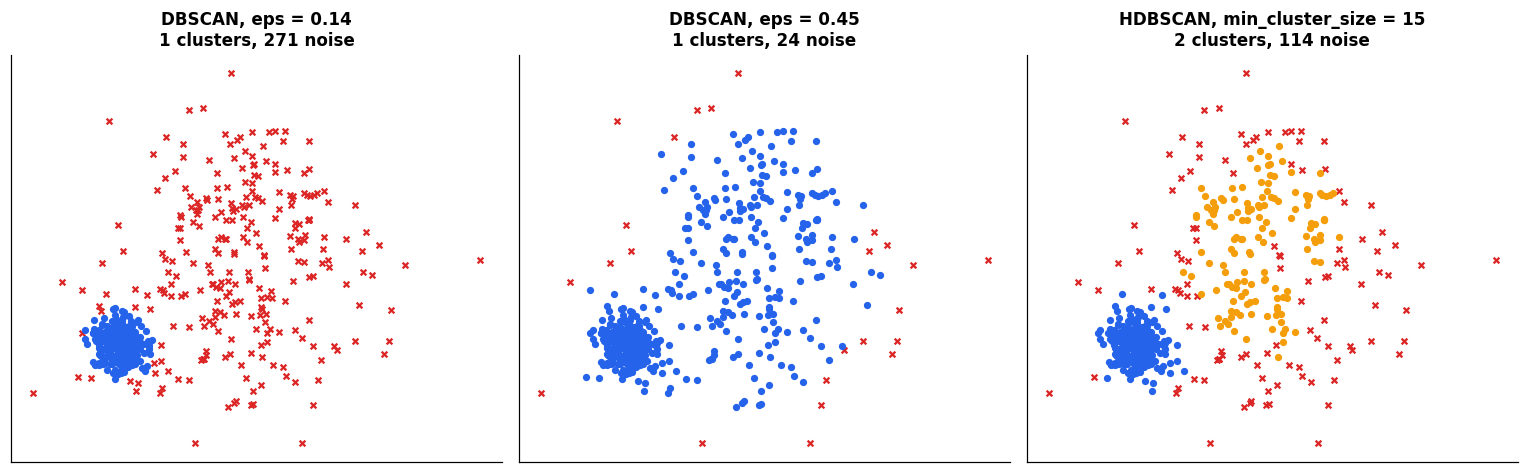

Neither eps works: 0.14 dissolves the sparse cluster into noise, 0.45 merges the two.
HDBSCAN extracts clusters at their own density levels -- at the cost of trimming
the sparse cluster's fringe, which it reports as noise.


In [17]:
rng = np.random.default_rng(1)
tight = rng.normal([0.00, 0.00], 0.22, (260, 2))   # dense cluster
loose = rng.normal([1.80, 1.08], 0.85, (260, 2))   # sparse cluster, 4x the spread
D = StandardScaler().fit_transform(np.vstack([tight, loose]))

runs = [(DBSCAN(eps=0.14, min_samples=8).fit_predict(D), "DBSCAN, eps = 0.14"),
        (DBSCAN(eps=0.45, min_samples=8).fit_predict(D), "DBSCAN, eps = 0.45"),
        (HDBSCAN(min_cluster_size=15, copy=True).fit_predict(D), "HDBSCAN, min_cluster_size = 15")]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (lab, title) in zip(axes, runs):
    for k in sorted(set(lab)):
        m = lab == k
        c = "#dc2626" if k == -1 else palette[k % len(palette)]
        ax.scatter(*D[m].T, s=14, c=c, marker="x" if k == -1 else "o")
    ax.set_title(f"{title}\n{len(set(lab) - {-1})} clusters, {(lab == -1).sum()} noise",
                 fontweight="bold", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

print("Neither eps works: 0.14 dissolves the sparse cluster into noise, 0.45 merges the two.")
print("HDBSCAN extracts clusters at their own density levels -- at the cost of trimming")
print("the sparse cluster's fringe, which it reports as noise.")

**The fixes**

| situation | reach for |
|---|---|
| clusters of differing density | **OPTICS** (`sklearn.cluster.OPTICS`) — builds a reachability ordering and extracts clusters at multiple density levels |
| same, plus you want a hierarchy and fewer knobs | **HDBSCAN** — in scikit-learn ≥ 1.3 as `sklearn.cluster.HDBSCAN`; needs only `min_cluster_size` |
| you only care about outliers, not clusters | **LocalOutlierFactor**, **IsolationForest** |
| very large n, streaming | **BIRCH**, or DBSCAN on a subsample + the assigner from §8 |

Other honest limitations to state in the lecture:

- **Parameter sensitivity** — ε must be tuned, and the k-distance knee is a heuristic, not a proof.
- **High dimensions** — Euclidean distance concentrates; reduce dimension or change metric
  (`metric="cosine"`, `metric="manhattan"`, or a precomputed distance matrix for e.g. DTW on
  vibration waveforms).
- **Border-point ambiguity** — a border point reachable from two clusters is assigned to
  whichever is processed first, so `labels_` is not perfectly deterministic under row
  reordering. Cluster *membership of core points* is deterministic; border points are not.

---
# 10. Summary

1. DBSCAN clusters by **local density**, using two parameters, **ε** and **MinPts**.
2. It **discovers the number of clusters** and it is allowed to output **noise** — which makes
   one algorithm serve both regime discovery and anomaly detection.
3. **Standardise first**, choose MinPts ≈ 2·d, choose ε from the **k-distance knee**, then
   confirm your choice sits on a **stable plateau**.
4. In our fleet-monitoring case it recovered the three duty regimes (ARI ≈ 1.0) and flagged
   every injected fault (recall 1.00, precision ≈ 0.90) with no labels at all.
5. It has **no `.predict()`** — use a nearest-core-point rule for new readings.
6. Its one structural weakness is **varying density**; OPTICS and HDBSCAN are the answer.

---
# 11. Exercises

1. **Re-tune.** Set `MIN_SAMPLES = 4` and re-derive ε from a new k-distance plot. How do the
   number of clusters, the noise rate and the anomaly precision/recall change? Which parameter
   was more sensitive?
2. **Feature ablation.** Drop `acoustic_hf` and re-run the whole pipeline. Bearing faults are
   detected earliest by the HF acoustic band — how much recall do you lose without it?
3. **Scaling.** Replace `StandardScaler` with `RobustScaler` and with no scaling at all. Explain
   the results in terms of the geometry of the ε-ball.
4. **A fourth regime.** Extend `make_machine_data` with a new duty regime (say a cavitating
   condition: high vibration, *low* current, high acoustic). Does DBSCAN find it automatically?
   What does K-Means with k=3 do with it?
5. **Metric.** Re-run DBSCAN with `metric="manhattan"`. Does the knee move? Does the answer change?
6. **Compare.** Run `sklearn.cluster.HDBSCAN` (scikit-learn ≥ 1.3) on the same data with
   `min_cluster_size=15` and compare its noise set with DBSCAN's. Which readings do they disagree on?
7. **Trend it.** Bin the readings into 50-hour windows and plot the *fraction* of `-1` labels per
   window. Design an alarm rule on that curve and state its false-alarm rate.

---
### References

- M. Ester, H.-P. Kriegel, J. Sander, X. Xu, *A Density-Based Algorithm for Discovering Clusters
  in Large Spatial Databases with Noise*, KDD-96, pp. 226–231.
- E. Schubert, J. Sander, M. Ester, H.-P. Kriegel, X. Xu, *DBSCAN Revisited, Revisited: Why and
  How You Should (Still) Use DBSCAN*, ACM TODS 42(3), 2017. — the definitive parameter-tuning guidance.
- M. Ankerst, M. Breunig, H.-P. Kriegel, J. Sander, *OPTICS: Ordering Points To Identify the
  Clustering Structure*, SIGMOD 1999.
- scikit-learn user guide, §2.3 Clustering — <https://scikit-learn.org/stable/modules/clustering.html>
- ISO 10816 / ISO 20816 — mechanical vibration evaluation of machines by measurements on
  non-rotating parts.

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>